# Getting started

Welcome! This notebook runs on your computer and talks to the **Rust simulation kernel**.
You do **not** need to build the browser Studio or WASM — just follow the steps below.

## What you need

| Tool | Why | Install |
| --- | --- | --- |
| **Git** | Clone this repository | [git-scm.com](https://git-scm.com/) |
| **uv** | Fast Python package manager | [docs.astral.sh/uv](https://docs.astral.sh/uv/getting-started/installation/) |
| **Rust (rustup)** | Build the native `_core` extension via maturin | [rustup.rs](https://rustup.rs/) |

## Step-by-step setup

### 1. Clone the repository

```bash
git clone https://github.com/OliverEvans96/blueberries-voi.git
cd blueberries-voi
```

### 2. Install Python dependencies

From the repository root:

```bash
uv sync --python 3.11
```

### 3. Build the Rust extension

Still from the repo root (first build may take a few minutes):

```bash
uv run --python 3.11 maturin develop --release -m crates/voi_py/Cargo.toml
```

### 4. Start Jupyter Lab

```bash
export BLUEBERRIES_VOI_BACKEND=rust
uv run jupyter lab notebooks/
```

Open `19_build_your_own_controller.ipynb` and run the cells in order.
The first code cell should print **`Rust backend ready.`**

### Optional: register a Jupyter kernel

If your IDE's kernel picker does not see the project environment:

```bash
uv run --python 3.11 python -m ipykernel install --user --name blueberries-voi
```

Then select **blueberries-voi** as the notebook kernel.

## Troubleshooting

| Problem | What to try |
| --- | --- |
| **`uv: command not found`** | Install uv (see table above), then open a new terminal |
| **`rustc` / `cargo` not found** | Install Rust via rustup, then open a new terminal |
| **Import error for `blueberries_voi._core`** | Re-run Step 3 (`maturin develop …`) from the repo root |
| **Notebook falls back to Python backend** | Set `export BLUEBERRIES_VOI_BACKEND=rust` before starting Jupyter |
| **Training or benchmarks feel slow** | Lower `N_PARTICLES` in the parameters cell; the first Rust build is also slow |


# Build your own controller

This notebook teaches **Option A**: a Python controller drives the production
`EngineSession` (Rust kernel) in a simple loop:

1. Read belief + pipeline from `session.snapshot()`
2. Choose an order with your `controller.order(ctx)`
3. Advance physics + filter with `session.step(order_qty)`

We compare **Your controller** (your teachable Python policy) against **Oliver's controller**
— production damped survival-weighted ordering via `session.act(policy="damped_sw")`.

## What your controller sees (`ControllerContext`)

Each `order(ctx)` call is a **pre-step** view: filter posterior only, never
simulator ground truth. Observation channels change filter *values* inside
`ctx.belief` (same shape), not the API.

| Field | Meaning |
| --- | --- |
| `ctx.belief.freshness_grid` | Freshness knot values $f_k$ on the wire |
| `ctx.belief.lot_marginals` | Per-lot posterior $p_{\ell,k}$ over the grid |
| `ctx.posterior_units` | Optional summed belief mass (not truth inventory) |
| `ctx.demand_forecast` | Committed demand: `scale_mu`, `dow_means` |
| `ctx.inbound_pipeline` | Orders placed, not yet arrived `{arrival_day: units}` |
| `ctx.order_schedule` | Delivery weekdays + lead time |
| `ctx.can_order_today` | False on non-order days → return 0 |
| `ctx.store_economics` | Studio money knobs (`sell_price`, costs) — session config |
| `ctx.episode_day`, `ctx.step_seq` | Calendar day index and monotonic step counter |

**Not in `ctx`:** ground-truth lots, controller budgets, raw observations.
Profit scoring uses Studio P&L via `store_economics` after each step.


Import the library helpers and confirm the Rust backend is available.

In [1]:
%matplotlib inline

from __future__ import annotations

import os

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")

import matplotlib.pyplot as plt
from pathlib import Path

from tqdm.auto import tqdm

from blueberries_voi.backend import rust_available, warn_fallback_once
from blueberries_voi.controller.session_loop import (
    ControllerContext,
    ControllerStepLog,
    EpisodeTotals,
    default_session_config,
    episode_totals_from_logs,
    run_controller_session,
)
from blueberries_voi.experiments.voi_profit import load_damped_sw_bo_params
from blueberries_voi.filter.types import ObsChannels
from blueberries_voi.sim.case_round import case_round
from blueberries_voi.sim.profit import StoreEconomics
from blueberries_voi.sim.shipments import default_shipments
from blueberries_voi.simulator import EngineSession

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})

warn_fallback_once()
if not rust_available():
    raise RuntimeError(
        "Rust backend unavailable. From repo root run:\n"
        "  uv run --python 3.11 maturin develop --release -m crates/voi_py/Cargo.toml\n"
        "then: export BLUEBERRIES_VOI_BACKEND=rust"
    )
print("Rust backend ready.")


Rust backend ready.


### Simulation parameters

Every simulator, logistics, filter, and economics knob is named below (with a comment
above each variable). `SESSION_CFG` and `STORE_ECONOMICS` are built from those names only.

Observation channels match the Studio **Observation** pane (three independent switches —
not named ladder presets like P1). The filter always runs; controllers always receive
filter-derived belief via `ControllerContext`.

Smaller particle counts run faster in a notebook while keeping the same calendar and
filter structure. **tqdm** shows progress during multi-seed evaluation.


In [2]:
# --- Reproducibility ---

# EVAL_SEEDS: paired multi-policy evaluation seeds (identical SESSION_CFG per arm)
EVAL_SEEDS = [11, 23, 37, 41, 53]

# --- Horizon ---

# N_DAYS: calendar days scored per controller episode
N_DAYS = 28

# --- Logistics ---

# LEAD_TIME_DAYS: order-to-arrival lag in calendar days
LEAD_TIME_DAYS = 1

# DELIVERY_WEEKDAYS: weekday encoding Mon=0 .. Sun=6; MWF = (0, 2, 4)
DELIVERY_WEEKDAYS = (0, 2, 4)

# --- Shipments ---

# SHIPMENTS: fitted MOD-21 demo traces (production default; parquet-free)
SHIPMENTS = default_shipments()

# --- Filter / belief wire ---

# ENABLE_FILTER: run particle filter on store observations
ENABLE_FILTER = True

# N_PARTICLES: particle filter size (lower = faster notebook)
N_PARTICLES = 64

# L_WIRE: max live lots on shelf (belief wire L)
L_WIRE = 10

# K_WIRE: freshness grid bins per lot (belief wire K)
K_WIRE = 30

# --- Observation (Studio three-channel pane) ---

# OBS_CODE_TYPE: register code — "upc" (storewide) or "gsin" (lot-resolved)
OBS_CODE_TYPE = "upc"

# OBS_SCAN_WASTE: whether daily spoilage counts reach the filter
OBS_SCAN_WASTE = True

# OBS_DELIVERY_HISTORY: supplier metadata — "none", "pack_date", or "temperature_history"
OBS_DELIVERY_HISTORY = "none"

OBS_CHANNELS = ObsChannels(
    code_type=OBS_CODE_TYPE,
    scan_waste=OBS_SCAN_WASTE,
    delivery_history=OBS_DELIVERY_HISTORY,
)

# --- Damped SW benchmark (Rust act() only) ---

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "blueberries_voi").is_dir():
    REPO_ROOT = REPO_ROOT.parent

BO_JSON = REPO_ROOT / "outputs" / "damped_sw_alpha_bo.json"
SW_ALPHA, SW_RHO = load_damped_sw_bo_params(BO_JSON)

# --- Economics (Studio pricing pane) ---

# P_SELL: retail sell price per unit ($)
P_SELL = 4.5

# C_UNIT: purchase / wholesale cost per arriving unit ($)
C_UNIT = 1.8

# C_WASTE: cost per spoiled unit ($)
C_WASTE = 1.2

# C_STOCKOUT: penalty per lost sale ($)
C_STOCKOUT = 2.5

STORE_ECONOMICS = StoreEconomics(
    sell_price=P_SELL,
    purchase_cost=C_UNIT,
    waste_cost=C_WASTE,
    stockout_penalty=C_STOCKOUT,
)

SESSION_CFG = default_session_config(
    shipments=SHIPMENTS,
    lead_time=LEAD_TIME_DAYS,
    delivery_weekdays=list(DELIVERY_WEEKDAYS),
    enable_filter=ENABLE_FILTER,
    obs_channels=OBS_CHANNELS,
    n_particles=N_PARTICLES,
    L=L_WIRE,
    K=K_WIRE,
)


### Controller parameters

**Your controller** tops up to a fixed shelf target. **Oliver's controller** is scored
via Rust `session.act(policy="damped_sw")` — not reimplemented here.

Edit `NaiveBaseStockController` in the next cell, or replace it with your own policy.


In [3]:
# --- Controller hyperparameters ---

# BASE_STOCK_TARGET: naive top-up target (units on shelf + pipeline)
BASE_STOCK_TARGET = 48

# CASE_SIZE: units per case (orders round to whole cases)
CASE_SIZE = 8


## Your controller

`NaiveBaseStockController` is a minimal teachable starter for **Your controller**. It implements
`order(ctx: ControllerContext) -> int`.


In [4]:
# --- Example controller (teachable implementation) ---


class NaiveBaseStockController:
    """Top-up to ``target_units`` with case rounding; 0 on non-order days."""

    def __init__(
        self,
        *,
        target_units: int = 48,
        case_size: int = 8,
    ) -> None:
        self.target_units = int(target_units)
        self.case_size = int(case_size)

    def order(self, ctx: ControllerContext) -> int:
        if not ctx.can_order_today:
            return 0
        pipeline_units = sum(int(q) for q in ctx.inbound_pipeline.values())
        gap = max(
            0.0,
            float(self.target_units - ctx.posterior_units - pipeline_units),
        )
        return case_round(gap, self.case_size)


## Multi-seed benchmark

Score **Your controller** (Python) and **Oliver's controller** (Rust damped SW) on the same
evaluation seeds. Each seed fixes the demand path so profit, spoilage, and stockout comparisons
are **paired** (common random numbers).

The loop retains **episode totals** (for violins) and **daily profit series** per policy
per seed for the cumulative-profit chart below.


In [5]:
YOUR_CONTROLLER = "Your controller"
OLIVERS_CONTROLLER = "Oliver's controller"

your_controller = NaiveBaseStockController(target_units=BASE_STOCK_TARGET, case_size=CASE_SIZE)

POLICY_COLORS = {
    YOUR_CONTROLLER: "#4C72B0",
    OLIVERS_CONTROLLER: "#C44E52",
}

your_results: list[EpisodeTotals] = []
oliver_results: list[EpisodeTotals] = []
benchmark_daily: dict[tuple[str, int], list[float]] = {}


def _run_controller_daily(
    controller,
    seed: int,
    *,
    policy_label: str,
) -> tuple[list[ControllerStepLog], EpisodeTotals]:
    session = EngineSession()
    session.init(SESSION_CFG, seed=seed)
    logs = run_controller_session(
        session, controller, N_DAYS, store_economics=STORE_ECONOMICS
    )
    totals = episode_totals_from_logs(
        logs, seed=seed, policy_label=policy_label
    )
    return logs, totals


def _run_olivers_controller_daily(seed: int) -> tuple[list[ControllerStepLog], EpisodeTotals]:
    session = EngineSession()
    session.init(SESSION_CFG, seed=seed)
    logs: list[ControllerStepLog] = []
    for _ in tqdm(
        range(N_DAYS),
        desc=f"Oliver's controller days (seed={seed})",
        leave=False,
    ):
        delta = session.act(policy="damped_sw", alpha=SW_ALPHA, rho=SW_RHO)
        logs.append(ControllerStepLog.from_delta(delta, store_economics=STORE_ECONOMICS))
    totals = episode_totals_from_logs(
        logs, seed=seed, policy_label=OLIVERS_CONTROLLER
    )
    return logs, totals


for seed in tqdm(EVAL_SEEDS, desc="Benchmark seeds"):
    your_logs, your_totals = _run_controller_daily(
        your_controller, seed, policy_label=YOUR_CONTROLLER
    )
    your_results.append(your_totals)
    benchmark_daily[(YOUR_CONTROLLER, seed)] = [log.day_profit for log in your_logs]

    oliver_logs, oliver_totals = _run_olivers_controller_daily(seed)
    oliver_results.append(oliver_totals)
    benchmark_daily[(OLIVERS_CONTROLLER, seed)] = [log.day_profit for log in oliver_logs]

    tqdm.write(
        f"seed={seed}: your={your_totals.profit:.1f} oliver={oliver_totals.profit:.1f}"
    )

policy_groups = {
    YOUR_CONTROLLER: your_results,
    OLIVERS_CONTROLLER: oliver_results,
}


Benchmark seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Oliver's controller days (seed=11):   0%|          | 0/28 [00:00<?, ?it/s]

seed=11: your=-104.9 oliver=946.9


Oliver's controller days (seed=23):   0%|          | 0/28 [00:00<?, ?it/s]

seed=23: your=-207.2 oliver=1248.8


...

seed=37: your=-261.9 oliver=1244.9


Oliver's controller days (seed=41):   0%|          | 0/28 [00:00<?, ?it/s]

seed=41: your=44.2 oliver=730.0


Oliver's controller days (seed=53):   0%|          | 0/28 [00:00<?, ?it/s]

seed=53: your=-257.4 oliver=1150.0


### Fig 1 — cumulative profit over time

Day-by-day cumulative profit for a **paired eval seed** — pulled from
`benchmark_daily` populated in the benchmark loop (no re-simulation).


Your controller total profit (eval seed=11): -104.9
Oliver's controller total profit (eval seed=11): 946.9


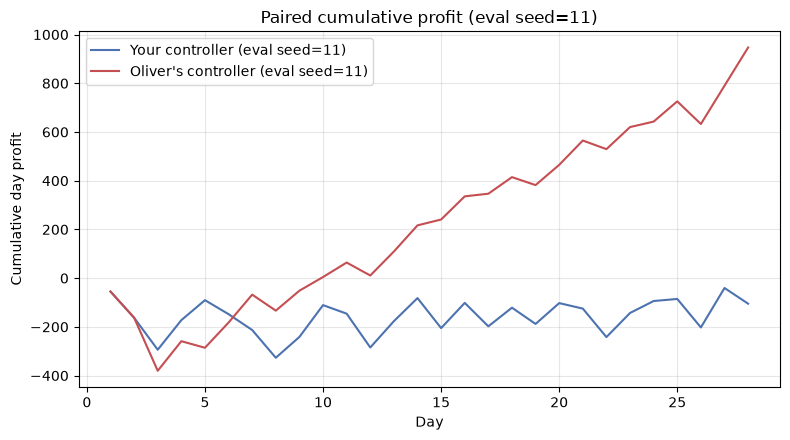

In [6]:
def cumulative(series: list[float]) -> list[float]:
    out: list[float] = []
    total = 0.0
    for x in series:
        total += x
        out.append(total)
    return out


eval_seed = EVAL_SEEDS[0]
your_daily = benchmark_daily[(YOUR_CONTROLLER, eval_seed)]
oliver_daily = benchmark_daily[(OLIVERS_CONTROLLER, eval_seed)]

print(f"Your controller total profit (eval seed={eval_seed}): {sum(your_daily):.1f}")
print(f"Oliver's controller total profit (eval seed={eval_seed}): {sum(oliver_daily):.1f}")

fig, ax = plt.subplots()
days = list(range(1, len(your_daily) + 1))
ax.plot(
    days,
    cumulative(your_daily),
    label=f"Your controller (eval seed={eval_seed})",
    color=POLICY_COLORS[YOUR_CONTROLLER],
)
ax.plot(
    days,
    cumulative(oliver_daily),
    label=f"Oliver's controller (eval seed={eval_seed})",
    color=POLICY_COLORS[OLIVERS_CONTROLLER],
)
ax.set_xlabel("Day")
ax.set_ylabel("Cumulative day profit")
ax.set_title(f"Paired cumulative profit (eval seed={eval_seed})")
ax.legend()
fig.tight_layout()
plt.show()


### Fig 2 — distribution across seeds (violins)

Violin width shows how each policy spreads over `EVAL_SEEDS`. Compare medians and
spread when choosing a deployment default.


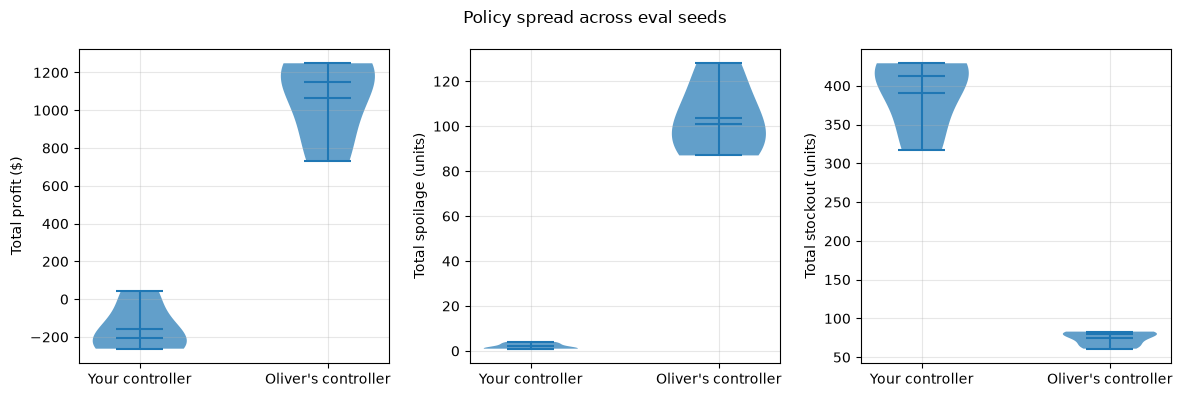

In [7]:
import numpy as np

BENCH_METRICS = [
    ("profit", "Total profit ($)"),
    ("waste", "Total spoilage (units)"),
    ("stockout", "Total stockout (units)"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (attr, ylab) in zip(axes, BENCH_METRICS, strict=True):
    data = [[getattr(row, attr) for row in policy_groups[name]] for name in policy_groups]
    parts = ax.violinplot(data, showmeans=True, showmedians=True)
    for body in parts["bodies"]:
        body.set_alpha(0.7)
    ax.set_xticks(np.arange(1, len(policy_groups) + 1))
    ax.set_xticklabels(list(policy_groups))
    ax.set_ylabel(ylab)
fig.suptitle("Policy spread across eval seeds")
fig.tight_layout()
plt.show()


## Next steps

- Replace `NaiveBaseStockController` with your own `order(ctx)` implementation.
- Feed richer state from `ctx.belief` (f-marginals per lot) or `ctx.demand_forecast`.
- Tune `BASE_STOCK_TARGET` against the same `run_controller_session` loop.
- Compare against **Oliver's controller** via `session.act(policy="damped_sw")`.
- Match Studio observation channels via `OBS_CODE_TYPE`, `OBS_SCAN_WASTE`, `OBS_DELIVERY_HISTORY`.
- Read ADR 0148 for why this path differs from `sim.episode.run_closed_loop_episode`.
